In [81]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.099  # Node power consumption in W
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/Almagro_2005_2023.csv"

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
    plot_pareto_front,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability
6. Compute Optimal solutions (Pareto Front)
7. Compute scores of the solutions in Pareto front

In [83]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [84]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.000100,0.011,0.70
1,0.000100,0.011,0.75
2,0.000100,0.011,0.80
3,0.000100,0.011,0.85
4,0.000100,0.011,0.87
...,...,...,...
3339,0.061102,3.200,0.85
3340,0.061102,3.200,0.87
3341,0.061102,3.200,0.90
3342,0.061102,3.200,0.95


In [85]:
## Explore Results

In [86]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.016000,0.75,0.98,8760,0,3212,0.830300,0.176906,125.097460,1128.100919,8760,0,1.50,0.650428,0.0,0.366667,-1003.003459,1.747799
1,0.016000,0.88,0.95,8760,0,3145,0.848194,0.156742,129.156258,1056.937315,8760,0,1.76,0.610437,0.0,0.359018,-927.781057,1.722888
2,0.016000,0.88,0.98,8760,0,3212,0.855369,0.150772,125.097460,1128.100919,8760,0,1.76,0.650428,0.0,0.366667,-1003.003459,1.707033
3,0.016000,1.10,0.90,8760,0,3017,0.867152,0.135107,136.536601,943.483992,8760,0,2.00,0.546604,0.0,0.344406,-806.947391,1.684189
4,0.016000,1.10,0.95,8760,0,3145,0.878555,0.125393,129.156258,1056.937315,8760,0,2.00,0.610437,0.0,0.359018,-927.781057,1.653901
5,0.016000,1.20,0.90,8760,0,3017,0.878223,0.123848,136.536601,943.483992,8760,0,1.20,0.546604,0.0,0.344406,-806.947391,1.652831
6,0.016000,1.10,0.98,8760,0,3212,0.884295,0.120618,125.097460,1128.100919,8760,0,2.00,0.650428,0.0,0.366667,-1003.003459,1.638046
7,0.010000,1.80,0.98,8760,0,2713,0.911308,0.095404,127.049462,665.853601,8760,0,3.60,0.396684,0.0,0.309703,-538.804138,1.634978
8,0.010057,1.80,0.98,8760,0,2716,0.911904,0.094270,127.021712,670.236108,8760,0,3.60,0.399095,0.0,0.310046,-543.214397,1.633333
9,0.016000,1.20,0.95,8760,0,3145,0.888675,0.114944,129.156258,1056.937315,8760,0,1.20,0.610437,0.0,0.359018,-927.781057,1.622543


## Best combinations

In [87]:
print(summary["score"].max())
best_configs = summary[summary["score"] == summary["score"].max()]

print(len(best_configs))

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

1.7477985612756406
1

panel_area_m2    0.016000
C_batt_Ah        0.750000
eta_PMU          0.980000
score            1.747799
Name: 0, dtype: float64


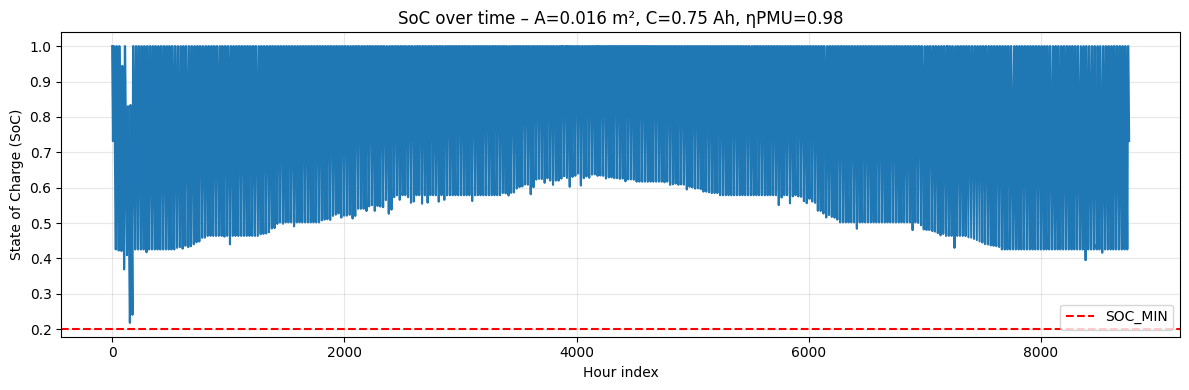

In [88]:
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [89]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [90]:
summary_plot = summary[summary["score"] > 0].copy()

fig = px.histogram(
    summary_plot,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution (score > 0)",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

In [91]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [92]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Viable configurations (score > 0): {len(summary[summary['score'] > 0])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 3344
Best score achieved: 1.7478
Configurations with best score: 1
Viable configurations (score > 0): 698
Configurations with failures: 2646
Configuration with I_req_max > I_batt_max): 862


## Invalidad configs due to < SoC_min

In [93]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
2125,0.000250,0.011,0.98,8760,1,0.011,0.027303
2124,0.000250,0.011,0.95,8760,1,0.011,0.028165
2123,0.000250,0.011,0.90,8760,1,0.011,0.029730
2118,0.000250,0.011,0.70,8760,1,0.011,0.038224
2347,0.000400,0.011,0.80,8760,1,0.011,0.033446
...,...,...,...,...,...,...,...
1681,0.031000,1.200,0.70,1,8584,1.200,0.650152
1177,0.040000,0.880,0.70,1,8607,1.760,0.844344
1688,0.031000,0.880,0.75,1,8607,1.760,0.747782
1350,0.056797,0.550,0.98,1,8607,1.000,2.375758


## Invalid configs due I_req > I_batt_max

In [94]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
438,0.061102,0.550,0.98,2.557819,1.000,0,8760
552,0.061102,1.100,0.98,2.557819,2.000,0,8760
597,0.061102,1.400,0.98,2.557819,2.000,0,8760
485,0.061102,0.750,0.98,2.557819,1.500,0,8760
507,0.061102,0.880,0.98,2.557819,1.760,0,8760
...,...,...,...,...,...,...,...
1857,0.000625,0.011,0.98,0.027303,0.011,8759,1
2085,0.001000,0.011,0.98,0.027303,0.011,7371,9
2125,0.000250,0.011,0.98,0.027303,0.011,8760,1
2352,0.000400,0.011,0.98,0.027303,0.011,8760,1


In [95]:
summary["autonomy_hours"].describe()


count    3344.000000
mean     3149.635467
std      3761.255760
min         1.000000
25%        19.750000
50%        95.000000
75%      8200.000000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [96]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
1857,0.000625,0.011,0.98,8760,8758,1,0.200093,0.008550,188.833373,0.00021,1,8759,0.011,0.027303,0.999772,0.000114,188.833163,0.0
2235,0.000100,0.011,0.87,8760,8759,1,0.200091,0.008547,261.358543,-0.00000,1,8760,0.011,0.030755,0.999886,0.000114,261.358543,0.0
2236,0.000100,0.011,0.90,8760,8759,1,0.200091,0.008547,252.378114,-0.00000,1,8760,0.011,0.029730,0.999886,0.000114,252.378114,0.0
2237,0.000100,0.011,0.95,8760,8759,1,0.200091,0.008547,238.671144,-0.00000,1,8760,0.011,0.028165,0.999886,0.000114,238.671144,0.0
2238,0.000100,0.011,0.98,8760,8759,1,0.200091,0.008547,231.118324,-0.00000,1,8760,0.011,0.027303,0.999886,0.000114,231.118324,0.0


In [97]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
2,0.016,0.88,0.98,8760,0,3212,0.855369,0.150772,125.097460,1128.100919,8760,0,1.76,0.650428,0.0,0.366667,-1003.003459,1.707033
31,0.016,1.60,0.90,8760,0,3017,0.908667,0.092886,136.536601,943.483992,8760,0,4.80,0.546604,0.0,0.344406,-806.947391,1.527400
1,0.016,0.88,0.95,8760,0,3145,0.848194,0.156742,129.156258,1056.937315,8760,0,1.76,0.610437,0.0,0.359018,-927.781057,1.722888
0,0.016,0.75,0.98,8760,0,3212,0.830300,0.176906,125.097460,1128.100919,8760,0,1.50,0.650428,0.0,0.366667,-1003.003459,1.747799
30,0.025,0.88,0.87,8760,0,3339,0.842397,0.167283,139.873485,1426.029973,8760,0,1.76,0.809962,0.0,0.381164,-1286.156489,1.529445


In [98]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.016000
C_batt_Ah        0.750000
eta_PMU          0.980000
score            1.747799
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.980000
score            0.074302
Name: 697, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.056797
C_batt_Ah        2.300000
eta_PMU          0.750000
score            0.498083
Name: 639, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.010057
C_batt_Ah        0.120000
eta_PMU          0.800000
score            0.000000
Name: 698, dtype: float64


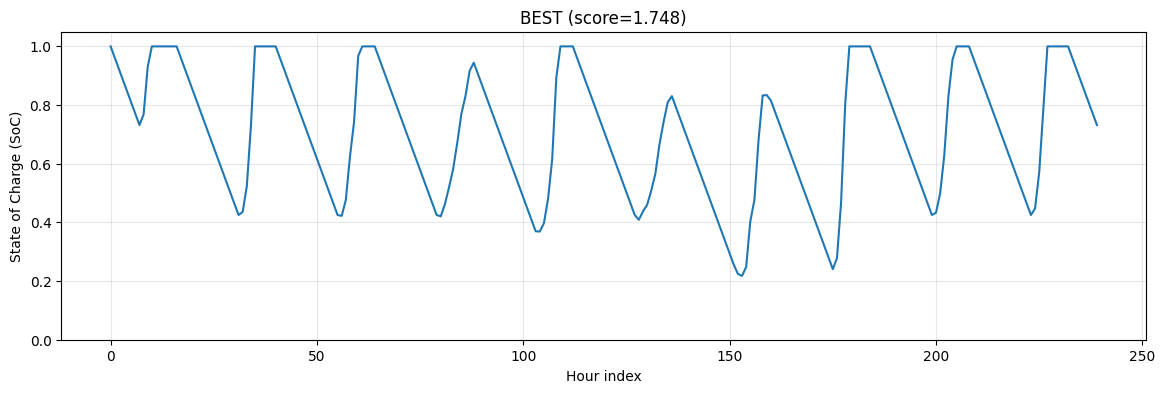

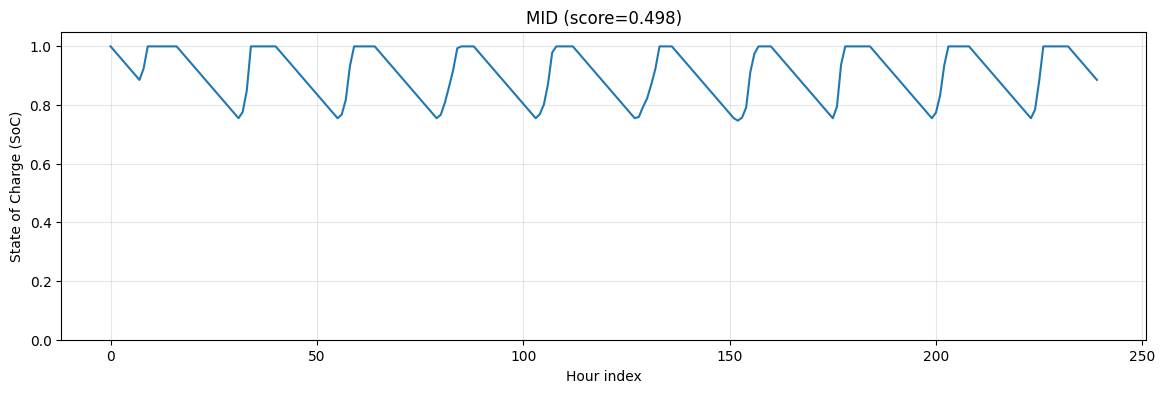

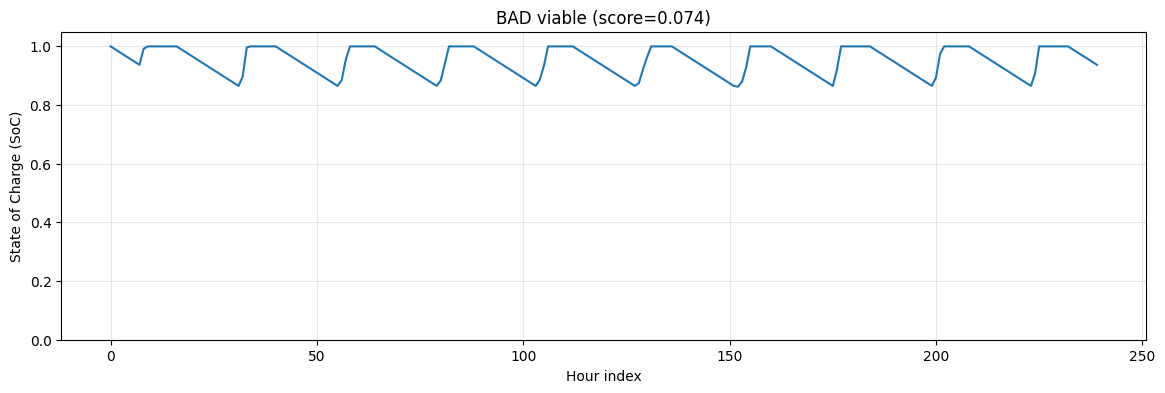

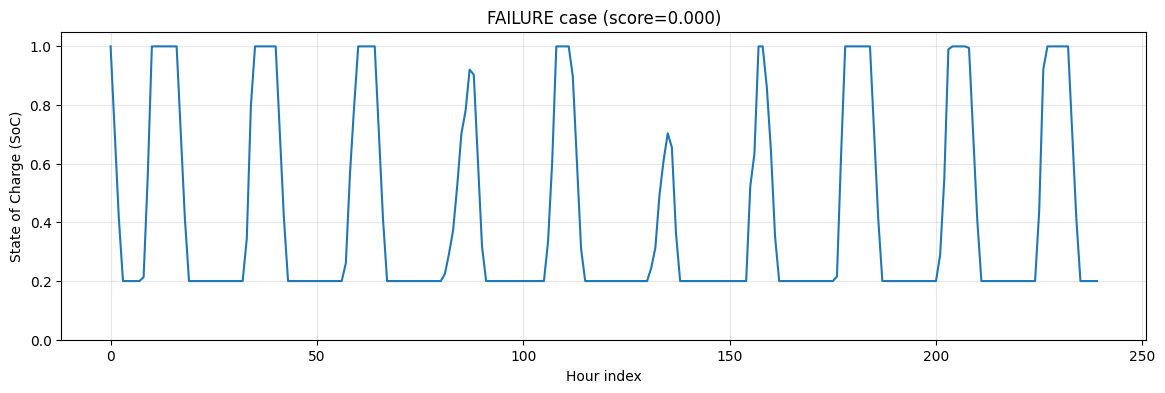

In [99]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [100]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


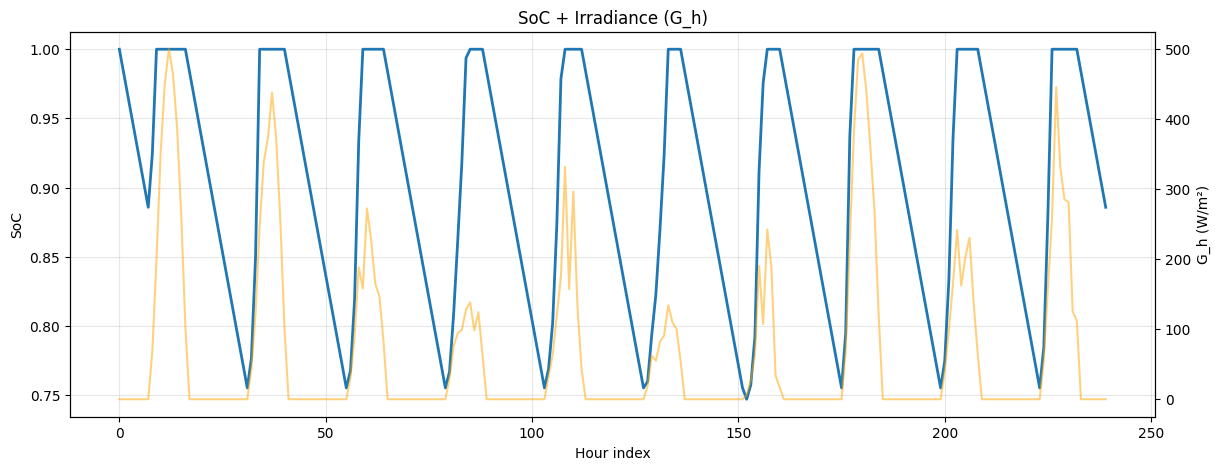

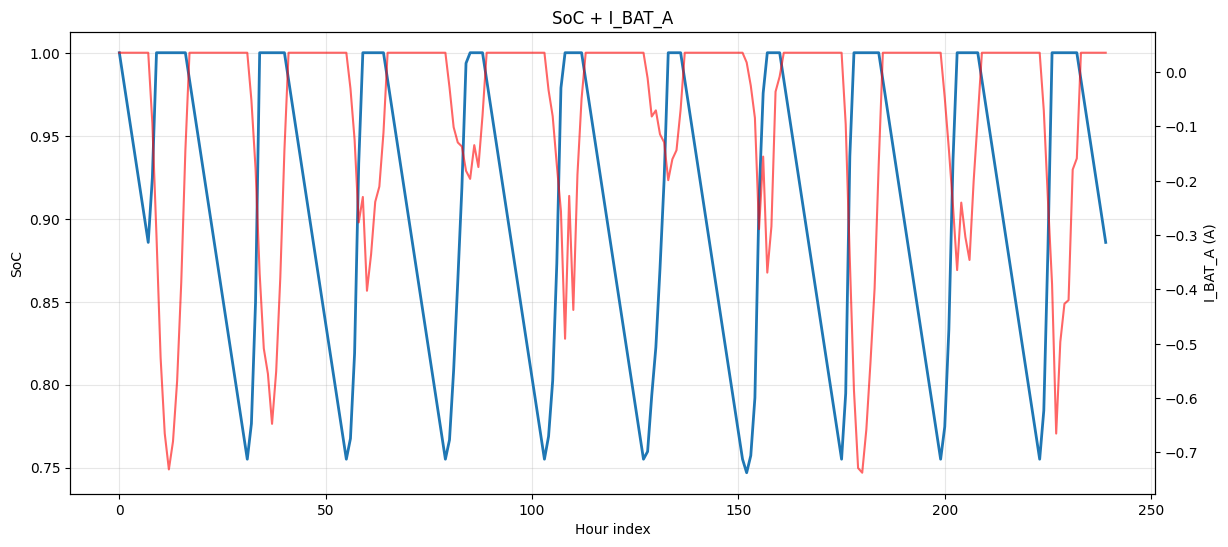

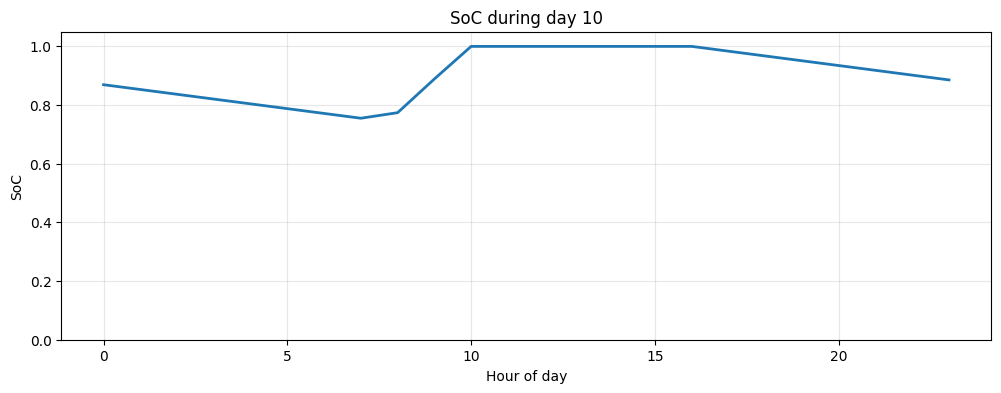

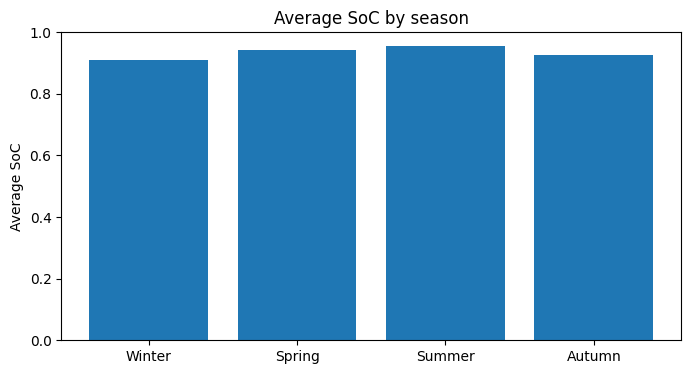

In [101]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [102]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.016000
C_batt_Ah        0.750000
eta_PMU          0.980000
score            1.747799
Name: 0, dtype: float64

MID: panel_area_m2    0.038500
C_batt_Ah        1.800000
eta_PMU          0.700000
score            1.042602
Name: 348, dtype: float64

BAD: panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.980000
score            0.074302
Name: 697, dtype: float64

FAIL: panel_area_m2    0.010057
C_batt_Ah        0.120000
eta_PMU          0.800000
score            0.000000
Name: 698, dtype: float64


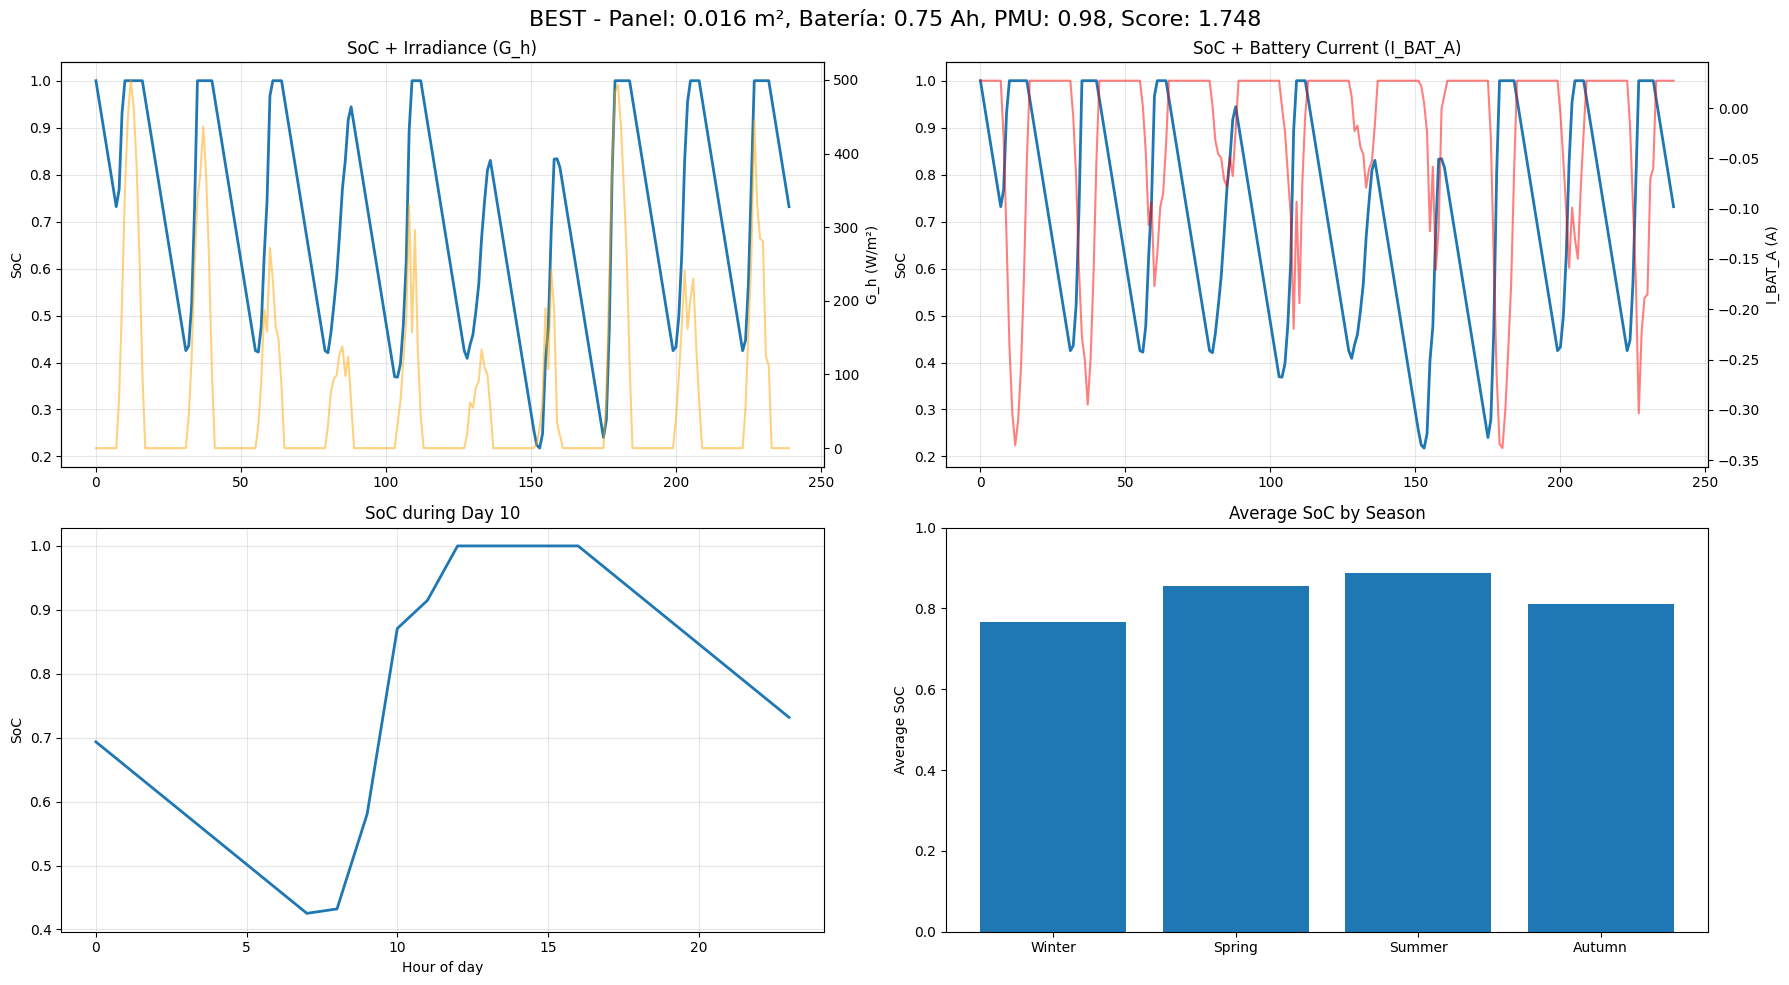

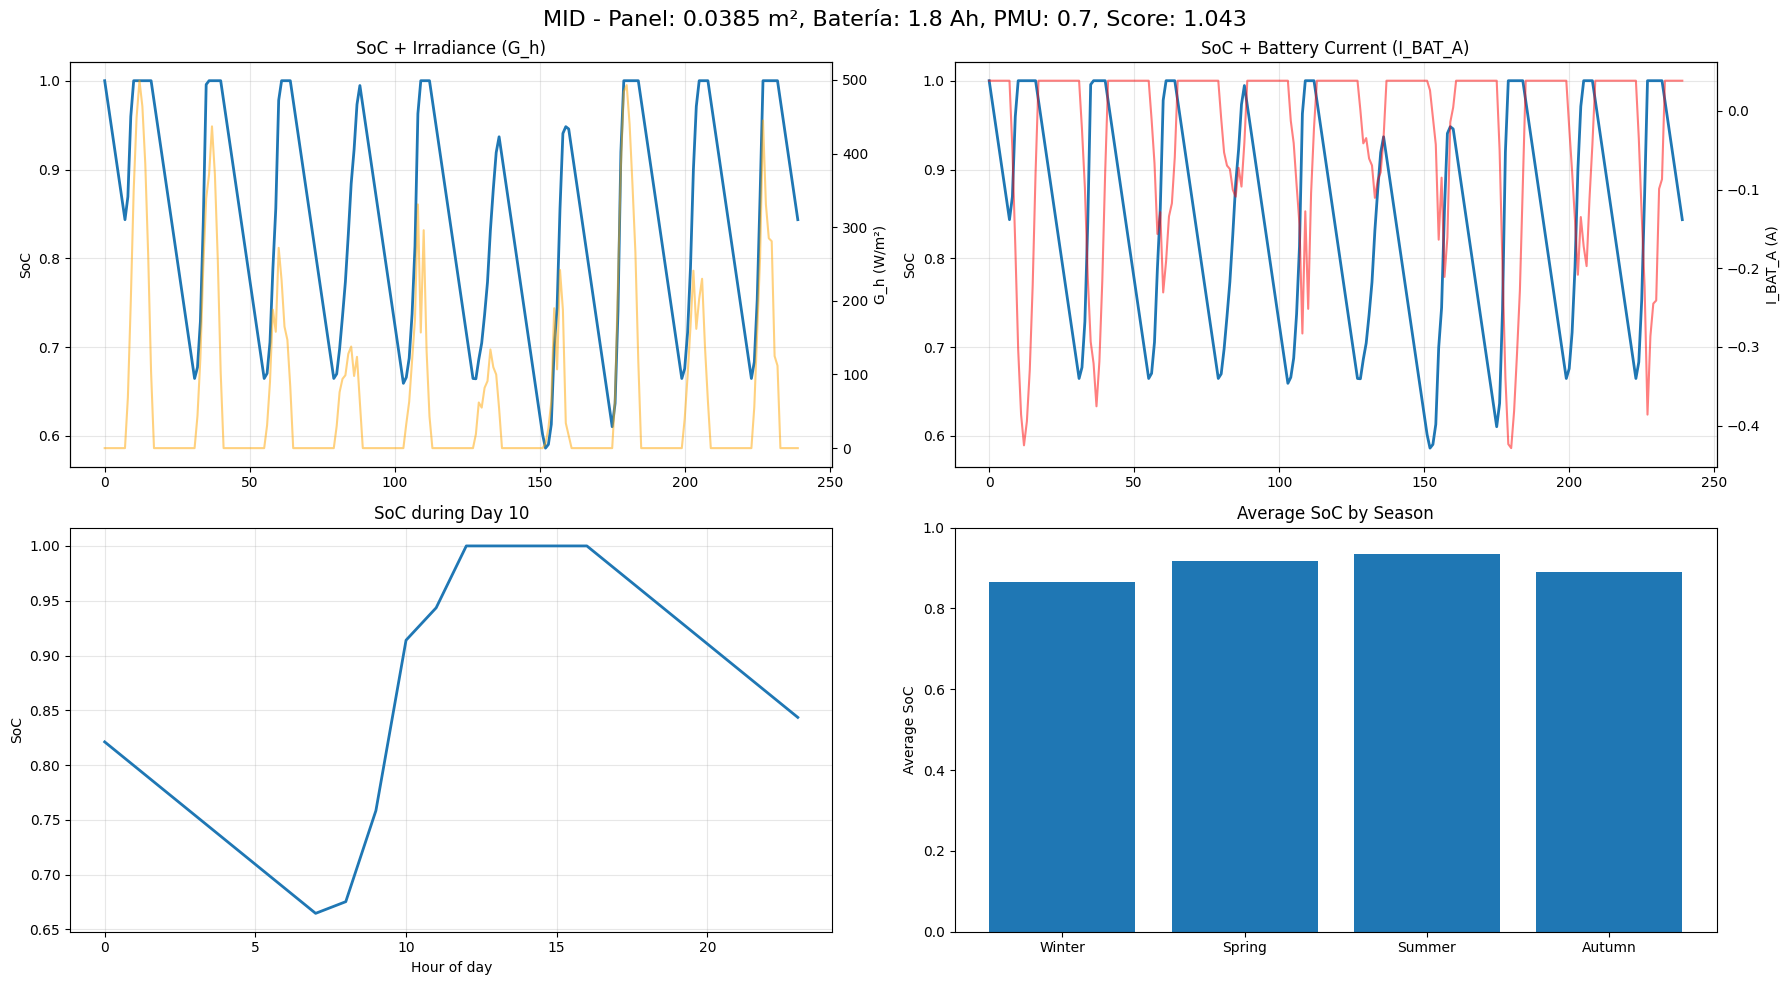

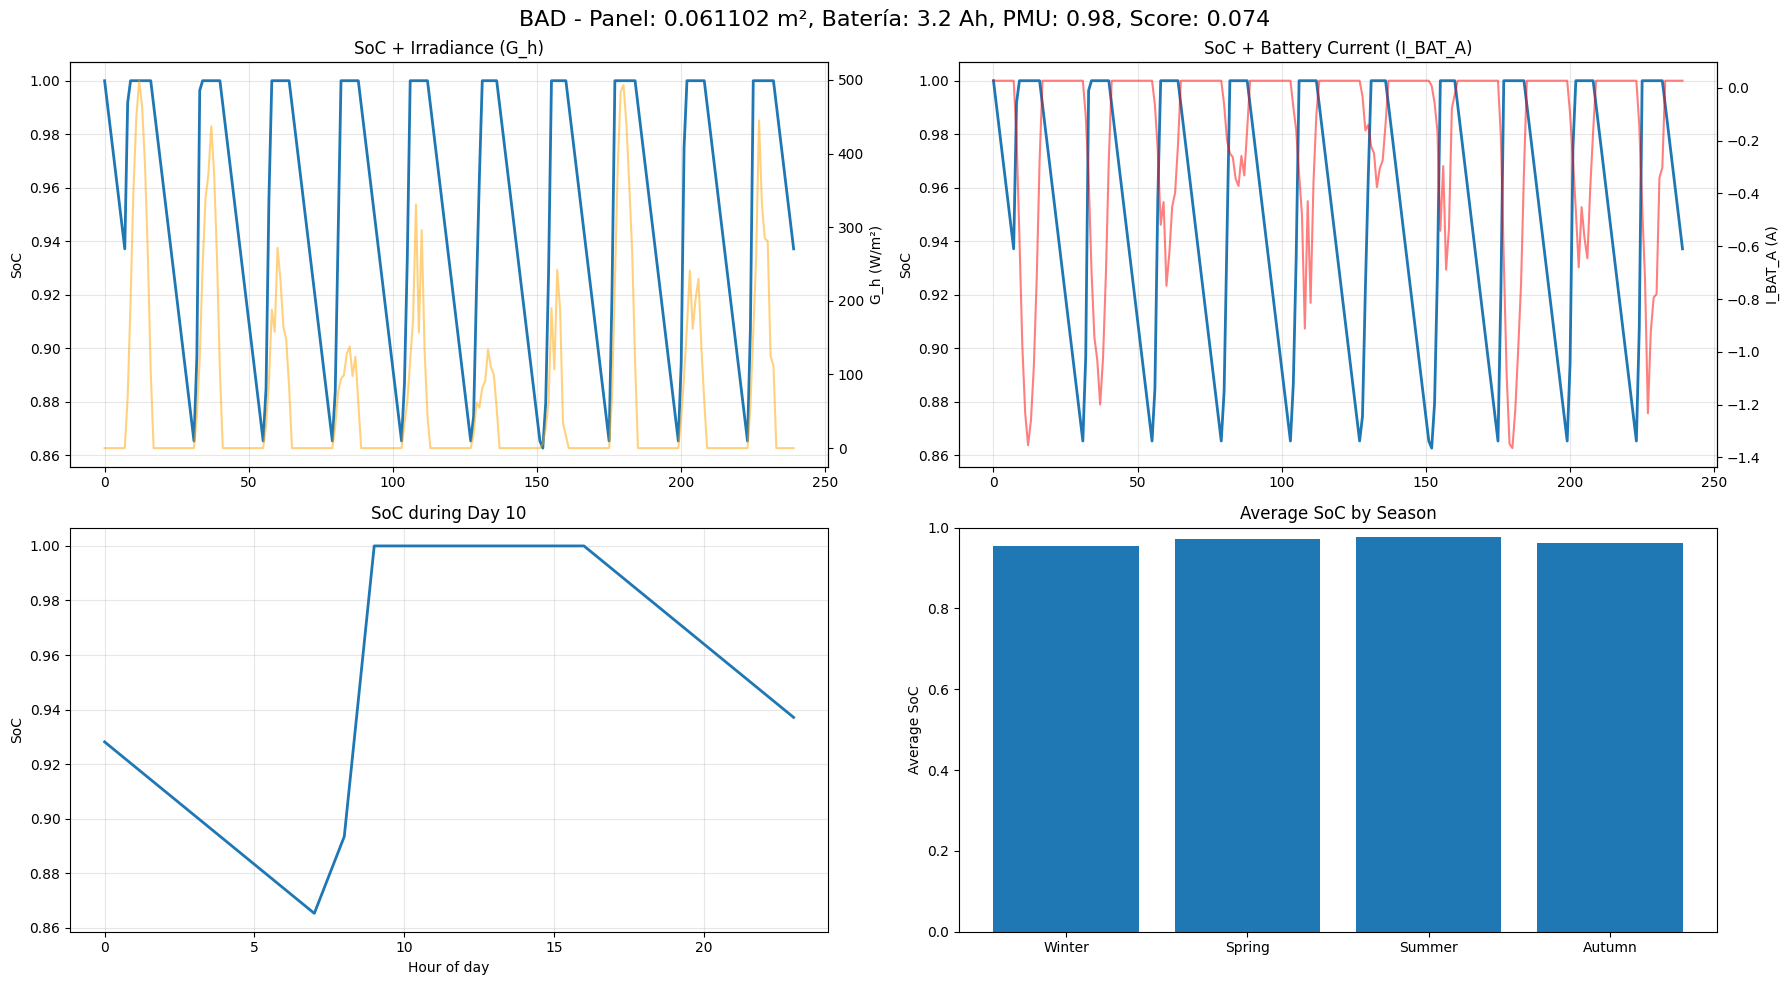

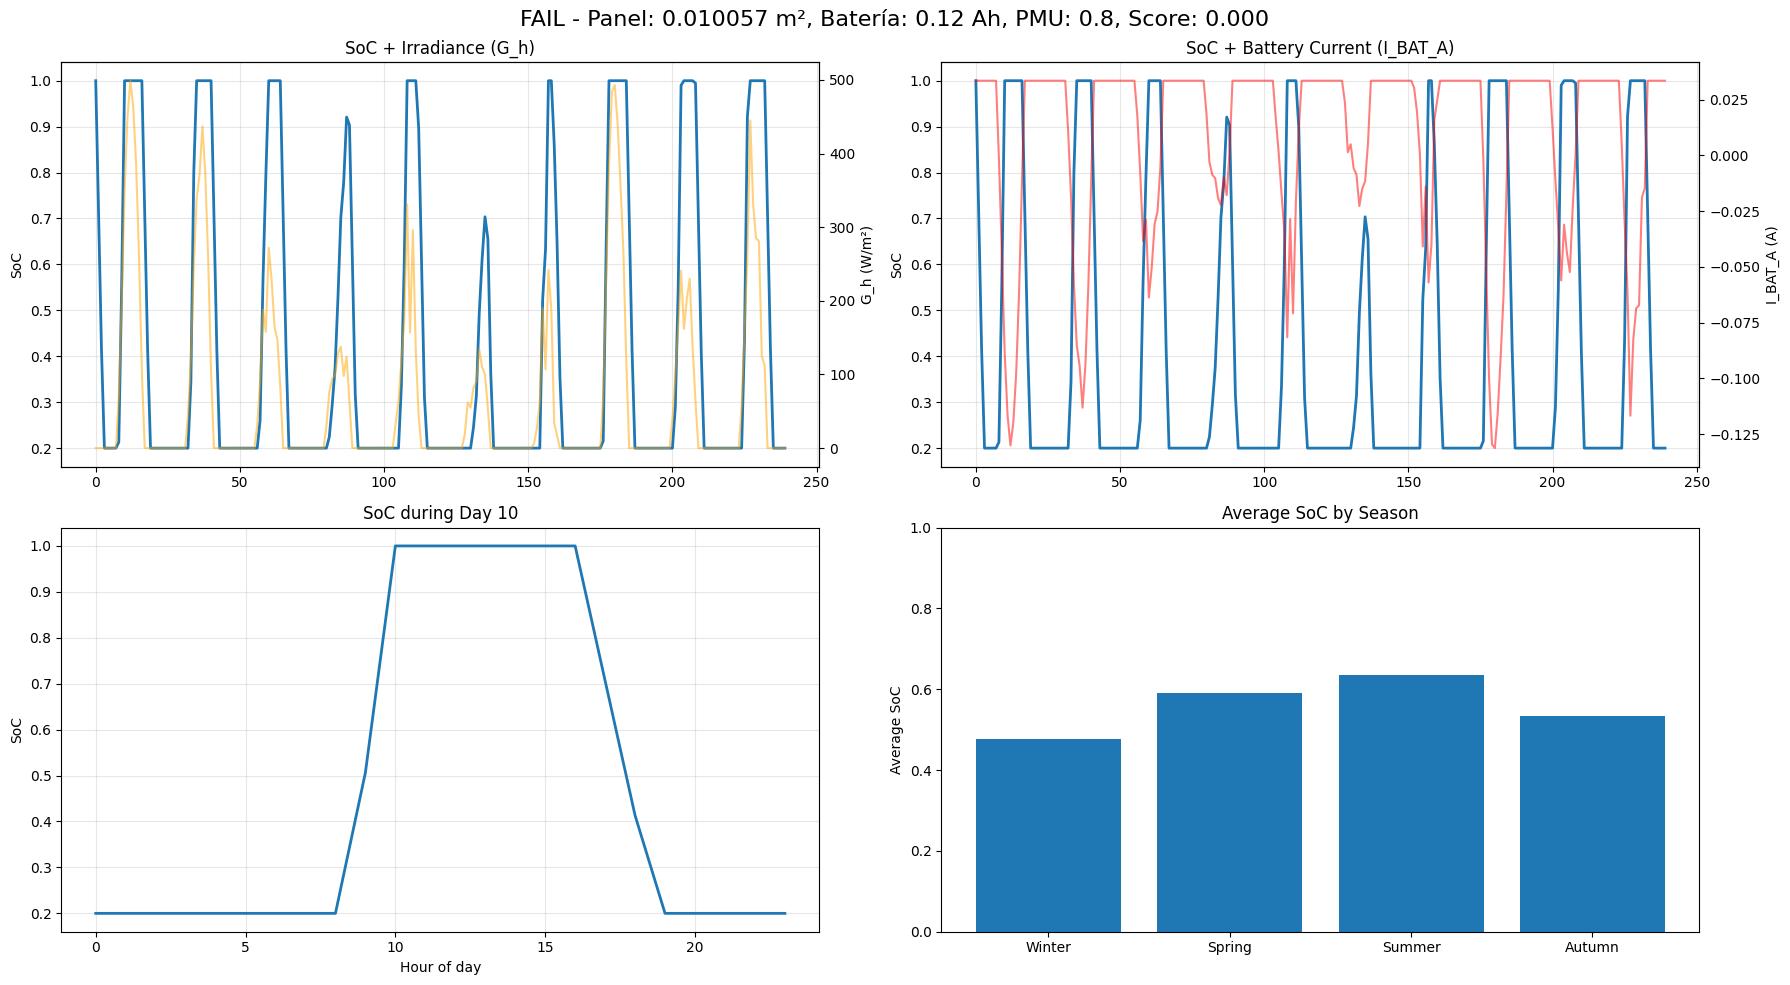

In [103]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)


## Pareto front

In [104]:
# ── Compute Pareto front ────────────────────────────────────────────────────
pareto_objectives = [
    ("C_batt_Ah",        -1),
    ("panel_area_m2",    -1),
    ("soc_full_fraction", -1),
]

front = simulator.pareto_front(summary, pareto_objectives)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

for i, row in front.iterrows():
    print(f"--- Config #{i} ---")
    print(f"  Panel area  : {row['panel_area_m2']*1e4:.1f} cm²  ({row['panel_area_m2']} m²)")
    print(f"  Battery     : {row['C_batt_Ah']} Ah")
    print(f"  η_PMU       : {row['eta_PMU']}")
    print(f"  SoC full    : {row['soc_full_fraction']*100:.1f}%")
    print(f"  Autonomy    : {row['autonomy_hours']} h")
    print(f"  Failures    : {int(row['failure_hours'])} h")
    print()


11 configurations on the Pareto front (out of 698 viable ones)

--- Config #0 ---
  Panel area  : 611.0 cm²  (0.061102 m²)
  Battery     : 0.55 Ah
  η_PMU       : 0.98
  SoC full    : 44.7%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #1 ---
  Panel area  : 250.0 cm²  (0.025 m²)
  Battery     : 0.7 Ah
  η_PMU       : 0.87
  SoC full    : 38.1%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #2 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 0.75 Ah
  η_PMU       : 0.98
  SoC full    : 36.7%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #3 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 0.88 Ah
  η_PMU       : 0.95
  SoC full    : 35.9%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #4 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 1.1 Ah
  η_PMU       : 0.9
  SoC full    : 34.4%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #5 ---
  Panel area  : 160.0 cm²  (0.016 m²)
  Battery     : 1.4 Ah
  η_PMU     

# Compute score from Pareto front¶
Pareto front¶

In [105]:
score_objectives = [
    ("surplus_Ah",        -0.33),
    ("eta_PMU",           -0.33),
    ("soc_std",           -0.34),
]

score = simulator.compute_score(front, score_objectives)

# columnas a mostrar
cols = [
    "panel_area_m2",
    "C_batt_Ah",
    "soc_full_fraction",
    "eta_PMU",
    "soc_mean",
    "soc_std",
    "surplus_Ah",
    "deficit_Ah",
    "hours_soc_full",
    "score",
]

tabla = score[cols]

# función para formatear valores
def fmt(v):
    if isinstance(v, float):
        return f"{v:.5f}"
    return str(v)

# calcular ancho máximo de cada columna
widths = []
for col in tabla.columns:
    max_data = tabla[col].map(fmt).map(len).max()
    widths.append(max(max_data, len(col)))

# encabezado
header = "  ".join(col.ljust(w) for col, w in zip(tabla.columns, widths))
print(header)

# línea separadora
print("-" * len(header))

# filas
for _, row in tabla.iterrows():
    line = "  ".join(fmt(v).ljust(w) for v, w in zip(row, widths))
    print(line)


panel_area_m2  C_batt_Ah  soc_full_fraction  eta_PMU  soc_mean  soc_std  surplus_Ah  deficit_Ah  hours_soc_full  score  
------------------------------------------------------------------------------------------------------------------------
0.01600        1.60000    0.32968            0.85000  0.89781   0.10411  144.80686   836.47131   2888.00000      0.64792
0.01600        1.40000    0.33630            0.87000  0.88859   0.11326  141.38257   878.50400   2946.00000      0.62456
0.01000        1.80000    0.30970            0.98000  0.91131   0.09540  127.04946   665.85360   2713.00000      0.60236
0.01000        2.00000    0.29920            0.95000  0.90991   0.10495  131.21936   622.65795   2621.00000      0.59270
0.01600        1.10000    0.34441            0.90000  0.86715   0.13511  136.53660   943.48399   3017.00000      0.56461
0.00800        3.20000    0.26164            0.95000  0.91625   0.12649  132.43887   478.37811   2292.00000      0.52007
0.00800        2.50000    0.2740

# Visualize SOC through year

Configuración seleccionada:
panel_area_m2    0.016000
C_batt_Ah        1.600000
eta_PMU          0.850000
score            0.647917
Name: 0, dtype: float64


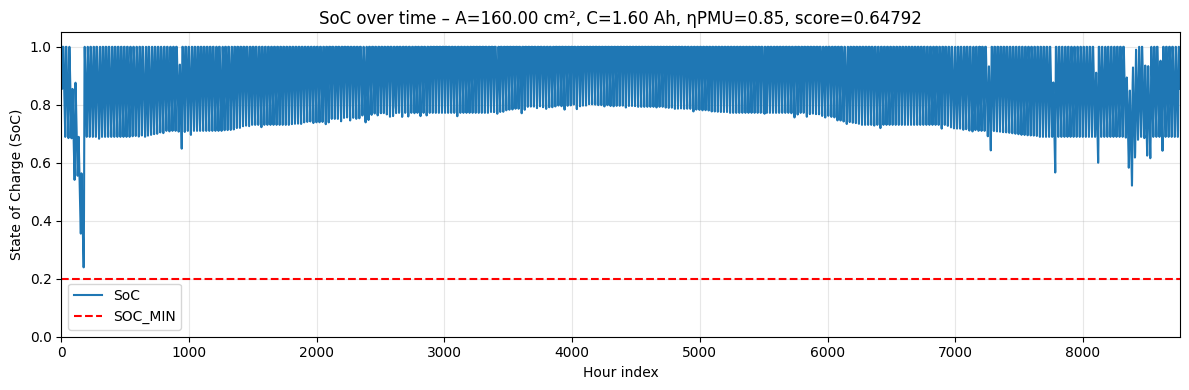

In [108]:
# Elegir la fila de la configuración que querés visualizar
row_idx = 0   # <-- cambiá este valor: 0, 1, 2, ...

# Tomar la configuración elegida desde el DataFrame score
cfg = score.iloc[row_idx]

# Filtrar df_soc para obtener la traza SoC de ESA configuración
config_soc = df_soc[
    (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
    (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
    (df_soc['eta_PMU'] == cfg['eta_PMU'])
].copy()

# Verificación opcional
print("Configuración seleccionada:")
print(cfg[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

# Gráfico anual del SoC
plt.figure(figsize=(12, 4))
plt.plot(config_soc['hour_index'], config_soc['SoC'], label='SoC')

plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
plt.ylim(0, 1.05)  # Limitar el eje y para mejor visualización
plt.xlim(0, 8760)  # Limitar el eje x a un año (8760 horas)
plt.xlabel('Hour index')
plt.ylabel('State of Charge (SoC)')
plt.title(
    f"SoC over time – A={cfg['panel_area_m2']*10000:.2f} cm², "
    f"C={cfg['C_batt_Ah']:.2f} Ah, ηPMU={cfg['eta_PMU']:.2f}, "
    f"score={cfg['score']:.5f}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Images/soc_plot_CR.png", dpi=600, bbox_inches='tight')
plt.show()
